In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from tqdm import tqdm
import json
import scipy as sp
import sys
import time
from seaborn import heatmap
sys.path.append("..")
# from sample_generation.workspace import Workspace
from sample_generation.signals import gaussian
# from sample_generation import workspace
from copy import deepcopy

/cvmfs/soft.computecanada.ca/easybuild/software/2020/avx512/Core/scipy-stack/2022a/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.25.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
class Histogram():
    def __init__(self, bkg, bin_edges, name, observed, signal):
        self.bkg = self.remove_nans(bkg).astype(float)
        self.name = name
        self.bin_edges = self.remove_nans(bin_edges).astype(float)
        self.bin_widths = np.diff(self.bin_edges)
        self.bin_centers = self.bin_edges[:-1] + self.bin_widths/2

        self.observed = self.remove_nans(observed).astype(float)
        self.signal = self.remove_nans(signal).astype(float)
        self.remove_negative()
        
    def remove_nans(self, array):
        return array[~np.isnan(np.array(array, dtype=float))]

    def remove_negative(self):
        self.bkg[self.bkg <= 0.0] == 0.0
        self.observed[self.observed <= 0.0] == 0.0

    def add_attr(self, attr_name, attr_data):
        """
        The method is used to add an attribute to the class
        """
        setattr(self, attr_name, attr_data)

    def plot(self, plot_bkg=True, plot_observed=True, plot_signal=True, plot_fit = False, plot_significance=False, save=False, plot_log_fit=False):
        nrows = 1 if not plot_signal else 2
        if (plot_signal or plot_predict) and plot_significance:
            nrows = 3
        gridspec_kw = {'height_ratios': [3] + [1]*(nrows-1), 'hspace': 0.05} if nrows != 1 else {}
        fig, ax = plt.subplots(nrows, 1, gridspec_kw=gridspec_kw, sharex=True, figsize=(6,6))
        if nrows == 1:
            ax = [ax]
        if plot_bkg:
            ax[0].errorbar(self.bin_centers, self.bkg, drawstyle='steps-mid', color='orange', label='Bkg', zorder=130)
            # ax[0].fill_between(bin_centers, bkg, step='mid', color='orange', label='Bkg', zorder=50)
        if plot_observed:
            ax[0].errorbar(self.bin_centers, self.observed, drawstyle='steps-mid', label='Observed', c='k', zorder=100)
            ax[0].fill_between(self.bin_centers, self.observed, step="mid", color='green', label='Observed', zorder=0)
        if plot_log_fit:
            ax[0].errorbar(self.bin_centers, self.bkg_log_fit, drawstyle='steps-mid', color='red', label="Log fit", zorder=150)
        if plot_signal:
            ax[1].errorbar(self.bin_centers, self.signal, drawstyle="steps-mid", label='signal', c="green")
            ax[1].set_ylabel("Entries", loc='top')
        if plot_fit:
            assert(plot_signal)
            ax[1].errorbar(self.bin_centers, self.signal_gaussian_fit, drawstyle="steps-mid", label='Fit', c="red")
        if plot_significance:
            assert(plot_signal)
            ax[2].errorbar(self.bin_centers, self.significance, drawstyle='steps-mid', label="$z_{PL}$ / $z_{max}$ = " + f"{np.max(zpl):.2f}", c="blue")
        for k in range(nrows):
            ax[k].legend()
            ax[k].tick_params(direction='in', which='both')
        ax[0].set_title(f"{self.name}")
        ax[0].set_ylabel("Entries", loc='top')
        if save:
            plt.savefig(f"{self.name}.png", bbox_inches='tight')
        

In [3]:
class BSMSample():
    def __init__(self, dir_path,
                 objects = ["B", "M", "C", "X", "S"],
                 out_dir="."):
        self.out_dir = out_dir
        self.dir_path = dir_path
        self.objects = objects
        
        self.background = np.array(pd.read_csv(dir_path + "B" + ".csv", header=None), dtype=object)
        self.bin_edges = np.array(pd.read_csv(dir_path + "M" + ".csv", header=None), dtype=object)
        self.names = np.array(pd.read_csv(dir_path + "C" + ".csv", header=None), dtype=object)
        self.signal = np.array(pd.read_csv(dir_path + "S" + ".csv", header=None), dtype=object)
        self.observed = np.array(pd.read_csv(dir_path + "X" + ".csv", header=None), dtype=object)
        
        self.histograms = [Histogram(self.background[i],
                                     self.bin_edges[i],
                                     self.names[i, 0],
                                     self.observed[i],
                                     self.signal[i]) for i in range(self.names.shape[0])]
        self.number_of_histograms = self.names.shape[0]
        
    def get_hist(self, idx):
        return self.histograms[idx]

    def save_info(self):
        zpls = []
        names = []
        mass_pred = []
        for hist in self.histograms:
            zpls.append(hist.significance)
            names.append(hist.name)
            mass_pred.append(hist.bin_centers[np.argmax(hist.significance)])
        np.save(self.out_dir + "/Z.npy", np.array(zpls, dtype=object))
        np.save(self.out_dir + "/Z_names.npy", np.array(names))
        np.save(self.out_dir + "/Z_mass.npy", np.array(mass_pred))

    def plot_heat_map(self, sigma=5):
        zmax = np.array([np.amax(hist.significance) for hist in self.histograms])
        mass = np.array([hist.bin_centers[np.argmax(hist.significance)] for hist in self.histograms])
        data = np.vstack([zmax, mass]).T
        df=pd.DataFrame(data=data, columns=['zmax', 'mpred']) 
        df['zmax'] = pd.to_numeric(df['zmax'])
        df['mpred'] = pd.to_numeric(df['mpred'])
        xdata = df[(df['zmax'] >= sigma)]['zmax'].to_numpy()
        ydata = df[(df['zmax'] >= sigma)]['mpred'].to_numpy()

        x_binning = np.arange(sigma, 25, 1)
        y_binning = np.arange(0, 2200, 100)
        
        fig, ax = plt.subplots(figsize=(8, 6), dpi=100, layout='tight')
        heatmap_data, x_binning, y_binning = np.histogram2d(xdata, ydata, bins=[x_binning, y_binning])
        ax = heatmap(heatmap_data.T, annot=True, cmap='Blues', cbar_kws={'label': 'Entries'})
        ax.set_title('Number of histograms as a function of predicted z and mass')
        ax.set_xlabel('Predicted Z')
        ax.set_ylabel('Predicted mass')
        plt.xticks(np.arange(len(x_binning)), ['{}'.format(i) for i in x_binning], rotation='horizontal')
        plt.yticks(np.arange(len(y_binning)), ['{}'.format(i) for i in y_binning], rotation='horizontal')
        plt.show()

This notebook uses it's own Workspace class since it needs to modify the one in the code to be able to not compute significance in bins with zero background.

In [4]:
class Workspace:

    def __init__(self, config=None, seed=None):

        ### settings
        self.config = config
        self.two_sided = True
        self.tol = 1e-4
        self.seed = seed
        self.rng = np.random.default_rng(self.seed)

        ### observable
        self.bin_edges = None
        self.bin_centers = None
        self.bin_widths = None

        ### functions
        self.sig_func = None
        self.bkg_func = None

        ### histograms
        self.data = np.array([])
        self.sig_hist  = np.array([])
        self.bkg_hist  = np.array([])

        ### parameters
        self.mu = 0.0  #signal strength
        self.M  = 0.0  #signal mass
        self.W  = 0.0  #signal width
        self.W_bins = 3.0 #signal width in bins

        ### read config
        if self.config is not None:
            self.read_config()
        self.update()

    def read_config(self):

        ### Takes path to json file or a dictionary
        if isinstance(self.config, str):
            self.config = json.load(open(self.config,'r'))

        for k,v in self.config.items():
            if hasattr(self,k):
                setattr(self,k,v)

    ### update bin quantities and update sig_hist
    def update(self):

        ### read bin edges from csv file
        if isinstance(self.bin_edges,str):
            self.bin_edges = np.genfromtxt(self.bin_edges, delimiter=',')

        ### calculate bin widths, centers based on bin edges
        if self.bin_edges is not None:
            if self.bin_widths is None:
                self.bin_widths = np.diff(self.bin_edges)
            if self.bin_centers is None:
                self.bin_centers = self.bin_edges[:-1] + self.bin_widths/2

        ### read histogram from csv file
        if isinstance(self.bkg_hist, str):
            self.bkg_hist = np.genfromtxt(self.bkg_hist, delimiter=',')

        ### update sig_hist based on current M, W
        if self.sig_func is not None:
            self.sig_hist = self.asimov(self.sig_func,params=(self.M,self.W))

    ### Takes pdf (function) and returns (normalized?) histogram where each bin is the integral of the pdf over that bin
    ### The integral is approximated by the value of the pdf at the bin center times the bin width (should be accurate for small bin widths)
    def asimov(self, pdf, params=None, normalize=True):

        assert callable(pdf)

        if params is None and pdf == self.sig_func:
            params = self.M, self.W

        hist = pdf(self.bin_centers, *params) * self.bin_widths
        if normalize:
            hist = hist/np.nansum(hist)
        return hist

    ### Takes histogram (pdf_hist) and draws new histogram by poisson fluctuating each bin
    ### By default it draws from the bkg + sig histogram of itself
    def sample(self, pdf_hist=None, atleast=1):

        if pdf_hist is None:
            pdf_hist = self.bkg_hist + self.mu * self.sig_hist

        ### Each bin must have at least <atleast> events
        min_bin, tries = 0, 0
        while min_bin < atleast and tries < 5:
            toy = self.rng.poisson(pdf_hist)
            min_bin = min(toy)
            tries += 1

        ### Replace 0 with 1
        if tries == 5:
            toy[toy == 0] = 1

        return toy

    ### Negative log-likehood
    def nll(self, mu=None, Nobs=None, Nexp=None, drop_const_term=True):

        if mu is None:
            mu = self.mu

        if Nobs is None:
            Nobs = self.data[self.bkg_hist != 0]
        
        if Nexp is None:
            Nexp = np.clip(self.bkg_hist[self.bkg_hist != 0] + mu * self.sig_hist[self.bkg_hist != 0],1e-12,None) # avoid log(0)
        
        nll = -np.sum( Nobs * np.log(Nexp) - Nexp)
        
        ### This term does not matter if you are calculating differences of nll values since Nobs is same under both hypotheses
        if drop_const_term == False:
            nll += np.sum(np.log(np.math.factorial(Nobs)))

        return nll

    ### Calculate q0 (negative log-likelihood ratio) and then take square-root to get z0
    ### mu_hat is needed only to check the sign of the best-fit signal strength, in case of a two-sided test
    def calc_z(self,nll_null,nll_alt,mu_hat=None):

        if mu_hat is None:
            mu_hat = self.mu

        z0, q0 = 0, 0

        if mu_hat >= 0:
            q0 = -2 * (nll_alt - nll_null)
            z0 = np.sqrt(q0)
        elif self.two_sided:
            q0 =  2 * (nll_alt - nll_null)
            z0 = -1*np.sqrt(-1*q0)

        return z0

    ### Fit mu to self.data by minimizing negative log-likelihood
    def fit(self):

        #Notes: Nelder-Mead is the original. Powell is faster, but it runs into problems. Might be worth checking L-BFGS-B.
        res = sp.optimize.minimize(self.nll, 0, (), 'Nelder-Mead', tol=self.tol)
        self.mu = res.x[0]
        # if not res.success:
        #     print('Fit did not converge!')
        return {'mu_hat': res.x[0], 'nll': res.fun, 'success': res.success}

    ### Hypothesis test: calculate z0 by calculating nll under null and alternative hypotheses
    ### If mu_inj is given, assume the data are bkg + mu_inj*sig
    def hypo_test(self, mu_inj=None):

        if mu_inj is not None:
            self.data = self.bkg_hist + mu_inj * self.sig_hist

        self.mu = 0
        nll_null = self.nll()
        fit_result = self.fit() #self.mu gets updated
        nll_alt  = fit_result['nll']
        z0 = self.calc_z(nll_null,nll_alt)
        return {'z0': z0, 'mu_hat': self.mu,  'nll_null': nll_null, 'nll_alt': nll_alt}

    ### Find the mu_inj that gives z0 = wanted_z
    def calc_mu_for_wanted_z(self, wanted_z):

        fun = lambda mu_inj: abs(self.hypo_test(mu_inj=mu_inj)['z0'] - wanted_z)

        mu_bounds = (0, 1e6) #Why are this the bounds?? -Eitan
        mu_for_wanted_z = scipy.optimize.golden(fun, brack=mu_bounds, tol=self.tol)

        assert abs(self.hypo_test(mu_inj=mu_for_wanted_z)['z0'] - wanted_z) < 1e-2

        return mu_for_wanted_z

    ### For each bin center, do a hypothesis test with signal centered there
    def z_scan(self):

        # Scan over M in bin centers and test significance of signal centered there
        z_scan = []
        for j, x_j in enumerate(self.bin_centers):
            self.M = x_j
            self.W = self.bin_widths[j]*self.W_bins
            self.update() ### update sig_hist
            z_scan.append(self.hypo_test()['z0'])

        return np.array(z_scan)

In [5]:
def inject_sig_and_scan(parameters):
    i, wksp, signal_mean, wanted_z, data_hist = parameters

    # Initialize signal histogram
    wksp.M        = wksp.bin_centers[signal_mean]
    wksp.W        = wksp.bin_widths[signal_mean]*wksp.W_bins
    
    # Save these for later (return)
    sig_inj = deepcopy(wksp.sig_hist)

    # Create the data by fluctuating bkg + mu_inj*sig (checking that it doesn't go below 1)
    wksp.data = data_hist

    # Scan over M in bin centers and test significance of signal centered there
    z_scan = wksp.z_scan()

    return i, wksp.data, signal_mean, z_scan, sig_inj

Define the sample:

In [7]:
bsm = BSMSample("/project/def-arguinj/shared/DDP_data/2023-11-08_dark_machines_rebinned_bsm_signals/Wprime_qqvv_HVT_chan3_100000/", out_dir="../bump_hunting/Wprime_qqvv_HVT_chan3_100000")

Utility functions

In [8]:
def ln(x, p0, p1, p2, p3, p4):
            return p0 + p1*x + p2*x**2 + p3*x**3 +p4*x**4

def gaussian_function(x, A, m, s):
    return A*np.exp(-(x-m)**2/(2*s**2))

In [9]:
import warnings
warnings.filterwarnings("ignore")

stop_copy = deepcopy(bsm)
CASE = 1 # 1 means the width is fixed, which always will be

for idx, hist in tqdm(enumerate(stop_copy.histograms), total = stop_copy.number_of_histograms):
    signal = hist.signal
    bin_centers = hist.bin_centers

    # We need to find approximate parameters for sp.optimize.curve_fit.
    # **
    # We approximate the amplitude with the max of the signal
    # the mean with the bin where signal is maximum and the width by twice the
    # width of the bin where the max is (to have width of  1 bin)
    # **
    bin_max_signal = np.nanargmax(signal)
    max_approx = np.nanmax(signal)
    mean_approx = bin_centers[bin_max_signal]
    width_approx = 2*(bin_centers[bin_max_signal - 1] - mean_approx)
    if CASE == 1:
        try:
            func = lambda x, A, m : gaussian_function(x, A, m, width_approx)
            popt, pcov = sp.optimize.curve_fit(func,  bin_centers, signal, p0=[max_approx, mean_approx])
            # print(idx)
        except:
            stop_copy.histograms[idx].add_attr("signal_gaussian_fit", [0]*len(signal))
            stop_copy.histograms[idx].add_attr("signal_gaussian_fit_params", {"max": 0, "mean": 0, "width": 0})
            continue
        fit = np.array(gaussian_function(bin_centers, popt[0], popt[1], width_approx))
        stop_copy.histograms[idx].add_attr("signal_gaussian_fit", fit)
        stop_copy.histograms[idx].add_attr("signal_gaussian_fit_params", {"max": popt[0], "mean": popt[1]})

100%|██████████| 13145/13145 [00:08<00:00, 1472.09it/s]


In [12]:
N = 0
# Let's loop over the signals to compute their significance:
null_bkg = ("ignore_zeros", None)
for idx, hist in tqdm(enumerate(stop_copy.histograms), total = stop_copy.number_of_histograms):
    signal = hist.signal
    popt = hist.signal_gaussian_fit_params
    
    # We use the mean of the fit.
    mean_idx = np.argmax(hist.signal_gaussian_fit)
    # We want to find the width of the fit in bins, so:
    if CASE == 1:
        width_of_sig = 1

    wksp_cfg = {
            'seed': idx,
            'bkg_hist': hist.bkg,
            'bin_edges': hist.bin_edges,
            'W_bins': width_of_sig, #signal width in bins
            'sig_func': gaussian,
        }
    
    parameters = [idx,
                    Workspace(wksp_cfg),      #workspace
                    mean_idx,             #position of injected sig
                    None,                     #significance of injected sig
                    hist.observed                      #observed data
                 ]
    _, _, _, zpl, _ = inject_sig_and_scan(parameters)
    N+=1
    stop_copy.histograms[idx].add_attr("significance", zpl)
stop_copy.save_info()

100%|██████████| 13145/13145 [09:08<00:00, 23.97it/s]


If you want to plot certain histograms according to their index:

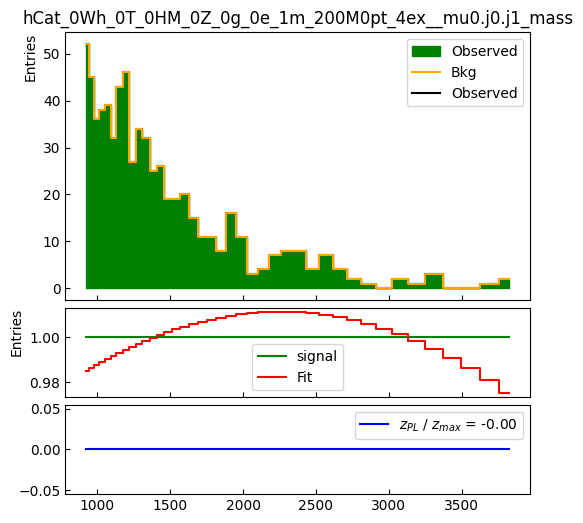

In [14]:
stop_copy.histograms[1500].plot(plot_bkg=True, plot_observed=True, plot_signal=True, plot_fit = True, plot_significance=True)

In [1]:
def plot_heat_map(bsm, sigma=5):
        zmax = np.array([np.amax(hist.significance) for hist in bsm.histograms])
        mass = np.array([hist.bin_centers[np.argmax(hist.significance)] for hist in bsm.histograms])
        data = np.vstack([zmax, mass]).T
        df=pd.DataFrame(data=data, columns=['zmax', 'mpred']) 
        df['zmax'] = pd.to_numeric(df['zmax'])
        df['mpred'] = pd.to_numeric(df['mpred'])
        xdata = df[(df['zmax'] >= sigma)]['zmax'].to_numpy()
        ydata = df[(df['zmax'] >= sigma)]['mpred'].to_numpy()

        x_binning = np.arange(sigma, 25, 1)
        y_binning = np.arange(0, 2200, 100)
        
        fig, ax = plt.subplots(figsize=(8, 6), dpi=100, layout='tight')
        heatmap_data, x_binning, y_binning = np.histogram2d(xdata, ydata, bins=[x_binning, y_binning])
        ax = heatmap(heatmap_data.T, annot=True, cmap='Blues', cbar_kws={'label': 'Entries'})
        ax.set_title('Number of histograms as a function of predicted z and mass')
        ax.set_xlabel('Predicted Z')
        ax.set_ylabel('Predicted mass')
        plt.xticks(np.arange(len(x_binning)), ['{}'.format(i) for i in x_binning], rotation='horizontal')
        plt.yticks(np.arange(len(y_binning)), ['{}'.format(i) for i in y_binning], rotation='horizontal')
        plt.show()
        fig.savefig(bsm.out_dir + "/heatmap.png", bbox_inches='tight')
plot_heat_map(stop_copy, 3)

NameError: name 'stop_copy' is not defined